# Lab 2: Entropy and Huffman Coding (2026 Version)

In this lab, you will learn how the statistical structure of an image can be used for compression.

You will:
- read a video file
- extract one frame
- convert the frame to a grayscale **Y** image
- compute the histogram and probability distribution
- calculate entropy
- build a Huffman code
- encode and decode the image
- compare entropy and practical coding rate

This lab connects image statistics, information theory, and lossless compression.

---

## Important

This is the lab notebook.  
You are expected to complete all **TODO** parts.

You may reuse code from Lab 1, but your final notebook must be:
- clean
- functional
- self-contained


## Group Information

**Group number:** 13

**Member 1:**  Erik Esshagen

**Member 2:**  Nora Sennerö

## Introduction

In many images, some pixel values occur more often than others.  
This means the image is not completely random, and that structure can be used for compression.

In this lab, you will explore a simplified lossless compression pipeline:

1. extract one frame from a video
2. convert the frame to the luminance channel \(Y\)
3. compute the histogram and probability distribution
4. calculate the entropy
5. build a Huffman dictionary
6. encode the image into a bitstream
7. decode the bitstream back into the original image
8. compare the achieved information rate with the entropy

This lab also shows a central principle of compression:

> **entropy gives a theoretical lower bound, while Huffman coding is a practical method that tries to approach it.**


## Learning Objectives

After completing this lab, you should be able to:

- extract one frame from a video file
- convert an RGB frame to a grayscale luminance image
- compute a histogram and probability distribution from image data
- explain what entropy measures
- compute entropy from a probability distribution
- implement a Huffman dictionary
- encode and decode an image using Huffman coding
- compute information rate and redundancy
- explain the relationship between entropy and practical coding performance


## Setup

Before starting, download the video file from Canvas and place it in the same folder as this notebook.

Then run the following cell to import the required libraries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import heapq
from collections import Counter

## Part 1: Read the Video and Extract One Frame

In this first part, you will load a video file and extract one frame.

### Task
- Open the video file
- Print basic information about the video
- Extract one frame
- Display the frame


Video information:
Width: 480
Height: 360
Frame rate: 30.0
Frame count: 141


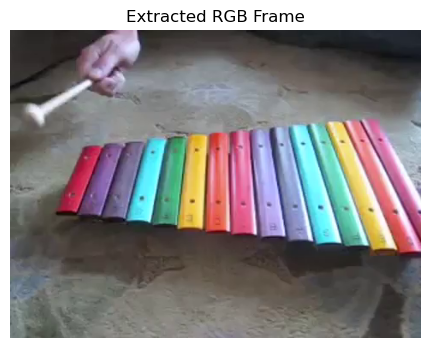

In [2]:
video_name = 'test video.mp4'
cap = cv2.VideoCapture(video_name)

if not cap.isOpened():
    raise ValueError("Could not open the video file. Please check the filename.")

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_rate = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("Video information:")
print("Width:", frame_width)
print("Height:", frame_height)
print("Frame rate:", frame_rate)
print("Frame count:", frame_count)

ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise ValueError("Could not read the first frame from the video.")

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(frame_rgb)
plt.title("Extracted RGB Frame")
plt.axis("off")
plt.show()

## Part 2: Convert RGB to the Y Channel

In video systems, the **Y** channel represents brightness (luminance-like information).  
In this lab, we use the Y channel as a grayscale image source for entropy coding.

### Task
Implement a function that converts an RGB image to a grayscale Y image.

### Hint
Use the following equation:

\[
Y = 0.2126R + 0.7152G + 0.0722B
\]

The output should be a 2D image with type `uint8`.


In [3]:
def frameRGB2Y(RGBframe):
    RGBframe = RGBframe.astype(np.float32)
    R = RGBframe[:, :, 0]
    G = RGBframe[:, :, 1]
    B = RGBframe[:, :, 2]

    Y = (0.299 * R) + (0.587 * G) + (0.114 * B)

    # TODO: clip into [0, 255] and convert to uint8
    Y = np.clip(Y, 0, 255).astype(np.uint8)
    return Y

## Part 3: Display the Y Image and Its Histogram

Now visualize the grayscale Y image and inspect its distribution of pixel values.

### Task
- Display the Y image
- Compute the histogram
- Plot the histogram


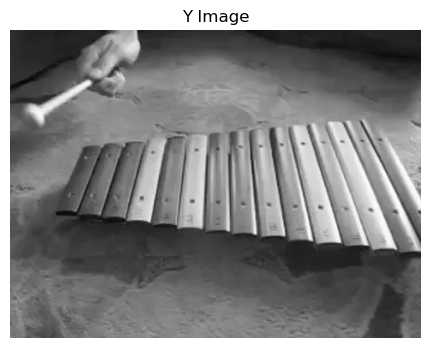

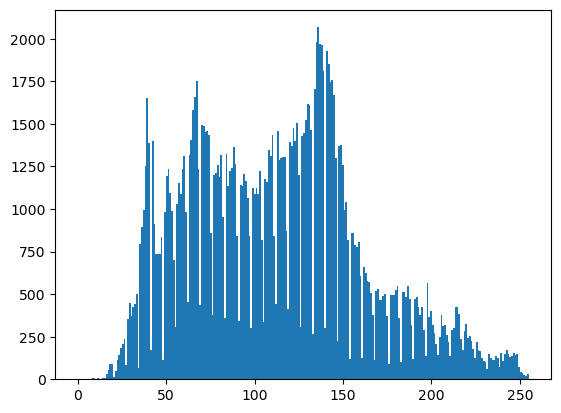

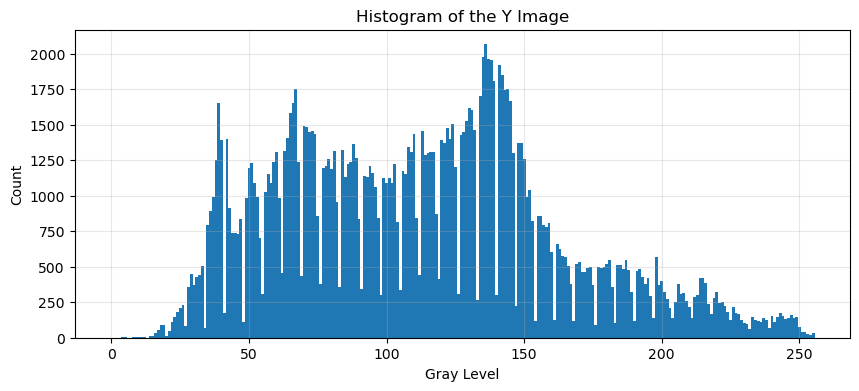

In [ ]:
Yframe = frameRGB2Y(frame_rgb)

plt.figure(figsize=(6, 4))
plt.imshow(Yframe, cmap='gray')
plt.title("Y Image")
plt.axis("off")
plt.show()

# TODO: compute histogram with 256 bins
hist, bin_edges, _ = plt.hist(Yframe.ravel(), bins=256, range=(0, 255))

plt.figure(figsize=(10, 4))
plt.bar(np.arange(256), hist, width=1.0)
plt.title("Histogram of the Y Image")
plt.xlabel("Gray Level")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

## Part 4: Compute the Probability Distribution

A histogram gives counts.  
To compute entropy, you need a probability distribution.

### Task
Convert the histogram into a probability distribution

\[
p(x) = \frac{\text{count}(x)}{\text{total number of pixels}}
\]

### Check
The probabilities should sum to 1.


In [9]:
# TODO: compute probability distribution
prob = hist / np.sum(hist)

print("Sum of probabilities:", np.sum(prob))

Sum of probabilities: 1.0


## Part 5: Calculate Entropy

Entropy measures the average uncertainty of the source.

### Formula

\[
H = -\sum_x p(x)\log_2 p(x)
\]

### Task
Implement a function that calculates the entropy of a probability distribution.

### Hint
You must ignore probability values equal to zero.


In [10]:
def CalculateEntropy(prob):
    # TODO: remove all zero probabilities
    prob_nonzero = prob[prob > 0]

    # TODO: compute entropy
    H = -np.sum(prob_nonzero * np.log2(prob_nonzero))
    return H

## Part 6: Test the Entropy Function

Now calculate the entropy of the Y image.

### Task
- Call your entropy function
- Print the entropy value
- Reflect: is it closer to 0 bits or to 8 bits?


In [8]:
entropy_value = CalculateEntropy(prob)
print("Entropy of the Y image:", entropy_value, "bits/pixel")

Entropy of the Y image: 7.472706127051253 bits/pixel


## Part 7: Build a Huffman Dictionary

Huffman coding assigns shorter codewords to more probable pixel values and longer codewords to less probable values.

### Task
Implement a function that builds a Huffman dictionary from the probability distribution.

### Output
The function should return a Python dictionary, for example

```python
{0: '10', 1: '111', 2: '0', ...}
```

### Hint
Use a priority queue (`heapq`).


In [18]:
def HuffmanDict(prob):
    # Create one heap node for every symbol with nonzero probability
    heap = [[p, [symbol, ""]] for symbol, p in enumerate(prob) if p > 0]
    heapq.heapify(heap)

    # TODO: repeatedly merge the two least probable nodes
    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)

        # TODO: prepend 0 to one branch and 1 to the other
        for pair in lo[1:]:
            pair[1] = "0" + pair[1]
        for pair in hi[1:]:
            pair[1] = "1" + pair[1]

        # TODO: push merged node back into the heap
        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])

    # Convert the result to a dictionary
    huff_list = sorted(heap[0][1:], key=lambda p: (len(p[1]), p))
    huff_dict = dict(huff_list)
    return huff_dict

## Part 8: Inspect the Huffman Dictionary

Now build the dictionary and inspect a few codewords.

### Task
- Create the Huffman dictionary
- Print the number of coded symbols
- Print a few example codewords


In [19]:
huff_dict = HuffmanDict(prob)

print("Number of coded symbols:", len(huff_dict))

example_items = list(huff_dict.items())[:10]
for symbol, codeword in example_items:
    print(symbol, "->", codeword)

Number of coded symbols: 251
135 -> 000010
136 -> 000111
137 -> 000000
37 -> 0001001
38 -> 0110101
39 -> 1101001
40 -> 1001011
42 -> 1001101
49 -> 0000010
50 -> 0101000


## Part 9: Encode the Y Image

Use the Huffman dictionary to convert the Y image into a bitstream.

### Task
Implement a function that:
- flattens the image into a 1D vector
- replaces every pixel value by its codeword
- concatenates the codewords into one bitstream

### Output
The output can be a Python string of bits.


In [21]:
def HuffmanEncode(Yframe, huff_dict):
    flat = Yframe.flatten()

    # TODO: replace each symbol by its Huffman codeword
    bitstream = "".join(huff_dict[symbol] for symbol in flat)
    return bitstream

## Part 10: Decode the Bitstream

Now reconstruct the original Y image from the Huffman bitstream.

### Task
Implement a decoder that:
- reads the bitstream bit by bit
- matches valid codewords
- reconstructs the pixel values
- reshapes the decoded vector to the original image shape

### Hint
A reverse dictionary is useful.


In [29]:
def HuffmanDecode(bitstream, huff_dict, shape):
    reverse_dict = {v: k for k, v in huff_dict.items()}

    decoded = []
    buffer = ""

    for bit in bitstream:
        buffer += bit

        # TODO: when buffer matches a valid codeword, append the decoded symbol
        if buffer in reverse_dict:
            decoded.append(reverse_dict[buffer])
            buffer = ""

    decoded = np.array(decoded, dtype=np.uint8)

    # TODO: reshape to the original image shape
    decoded = decoded.reshape(frame_height, frame_width)
    return decoded

## Part 11: Test Encoding and Decoding

Now test the full Huffman pipeline.

### Task
- encode the Y image
- decode it
- verify that the decoded image is identical to the original


In [30]:
bitstream = HuffmanEncode(Yframe, huff_dict)
Ydecoded = HuffmanDecode(bitstream, huff_dict, Yframe.shape)

print("Encoded bitstream length:", len(bitstream))
print("Decoded image shape:", Ydecoded.shape)
print("Reconstruction correct:", np.array_equal(Yframe, Ydecoded))

Encoded bitstream length: 1295822
Decoded image shape: (360, 480)
Reconstruction correct: True


## Part 12: Visual Comparison

Display the original Y image, the decoded Y image, and the difference image.

### Task
Show:
- original Y image
- decoded Y image
- absolute difference image

If the decoding is correct, the difference image should be all zeros.


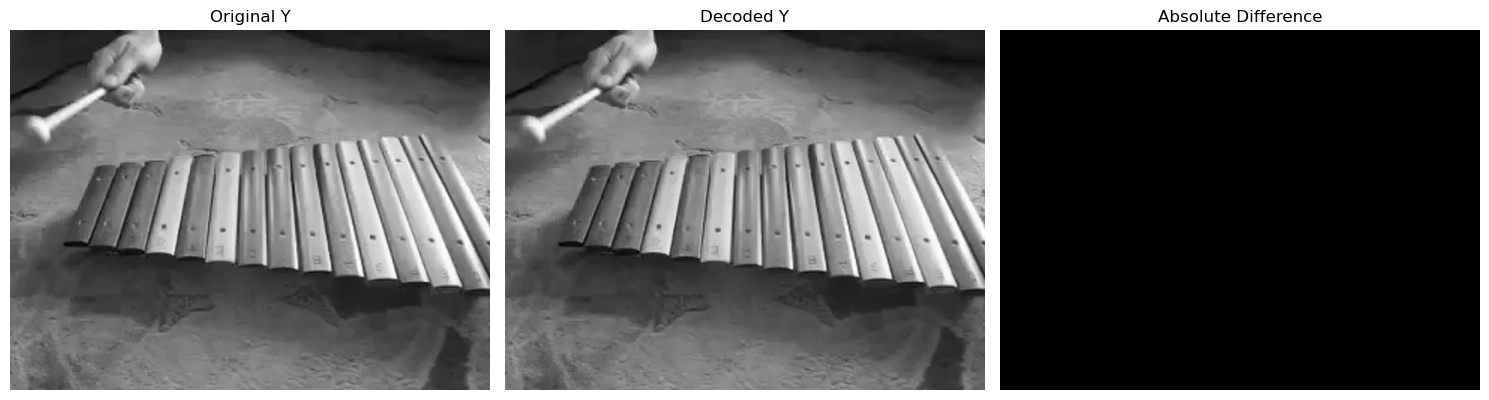

In [31]:
difference = np.abs(Yframe.astype(np.int16) - Ydecoded.astype(np.int16)).astype(np.uint8)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(Yframe, cmap='gray')
plt.title("Original Y")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Ydecoded, cmap='gray')
plt.title("Decoded Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference, cmap='gray')
plt.title("Absolute Difference")
plt.axis("off")

plt.tight_layout()
plt.show()

## Part 13: Compute Information Rate and Redundancy

The information rate of the encoded image is

\[
R = \frac{\text{number of bits in the bitstream}}{\text{number of pixels}}
\]

The redundancy is

\[
\text{Redundancy} = 8 - H
\]

### Task
- compute the information rate
- compute the redundancy
- compare the rate with the entropy


In [32]:
def CalculateRate(bitstream, image_shape):
    num_pixels = image_shape[0] * image_shape[1]

    # TODO: compute the information rate
    R = len(bitstream) / num_pixels
    return R

rate_value = CalculateRate(bitstream, Yframe.shape)
redundancy_value = 8 - entropy_value

print("Entropy H:", entropy_value, "bits/pixel")
print("Information rate R:", rate_value, "bits/pixel")
print("Redundancy:", redundancy_value, "bits/pixel")

Entropy H: 7.472706127051253 bits/pixel
Information rate R: 7.498969907407408 bits/pixel
Redundancy: 0.5272938729487473 bits/pixel


## Part 14: Optional Experiment

Try the same pipeline on another frame from the video.

### Possible questions
- Does the entropy change from frame to frame?
- Does the Huffman rate also change?
- Are some frames easier to compress than others?


In [ ]:
# Optional: extract another frame and repeat the same analysis
# You may write your own code here.

## Part 15: Discussion Questions

Answer the following questions in your report:

1. What does entropy measure in this lab?
2. Why is the entropy of the Y image usually lower than 8 bits/pixel?
3. Why is Huffman coding effective for this type of data?
4. Why is the achieved information rate close to, but not always equal to, the entropy?
5. Why is the Y channel a reasonable choice for this lab instead of coding RGB directly?
6. If the histogram were almost uniform, what would happen to the entropy and compression performance?


## Report Instructions

Your report should contain:

1. group number and member names
2. a short explanation of the Y channel
3. the displayed Y image
4. the histogram of the Y image
5. the probability distribution method
6. the entropy value
7. a short description of your Huffman dictionary implementation
8. encoded and decoded results
9. proof that the decoded image matches the original
10. the information rate
11. the redundancy
12. short answers to the discussion questions

Submit:
- one PDF report
- one Jupyter notebook (`.ipynb`)

Make sure the notebook runs from start to finish.
